# Proyecto AgroTech: Entrenamiento y Evaluación de Modelos

Este notebook realiza el entrenamiento del modelo **XGBoost** para predecir condiciones climáticas, aplicando técnicas de balanceo de datos para mejorar la detección de eventos climáticos poco frecuentes (lluvia, tormentas, nieve).

## Importar librerias

In [1]:
# 1. Instalación de librerías necesarias
!pip install xgboost imbalanced-learn scikit-learn pandas numpy matplotlib seaborn rich ipywidgets

Defaulting to user installation because normal site-packages is not writeable


In [1]:
import pandas as pd
import numpy as np
import os
import glob
import time
import random
import warnings
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from joblib import dump
import matplotlib.pyplot as plt
import seaborn as sns
from rich.console import Console
from rich.table import Table

warnings.filterwarnings('ignore')
console = Console()

## Cargar datos

In [2]:
full_df = pd.read_csv('../weather_curico_preprocessed_redudancia.csv')
full_df['date'] = pd.to_datetime(full_df['date'])
full_df = full_df.sort_values(by='date').reset_index(drop=True)
split_index = int(len(full_df) * 0.7)

train_df = full_df.iloc[:split_index]
test_df = full_df.iloc[split_index:]

print(f"Registros de entrenamiento: {len(train_df)}")
print(f"Registros de test: {len(test_df)}")

Registros de entrenamiento: 26124
Registros de test: 11196


In [3]:
train_df.head()

,date,relative_humidity_2m,precipitation,cloud_cover,wind_speed_10m,weather_code,pressure_msl,is_day,vapour_pressure_deficit,et0_fao_evapotranspiration,soil_temperature_0_to_7cm,soil_moisture_0_to_7cm,weather_condition,VPD,water_balance,heat_stress_duration
0,2022-01-01 00:00:00+00:00,-1.402662,-0.163788,-1.021382,1.584886,-0.36605,-1.407699,1.0,1.113748,-0.015234,1.571177,-0.849147,Sunny,1.113554,-0.144965,-0.283982
1,2022-01-01 01:00:00+00:00,-1.294097,-0.163788,-1.021382,2.001583,-0.36605,-1.183064,0.0,0.896396,-0.082951,1.327163,-0.849147,Sunny,0.896099,-0.123124,-0.283982
2,2022-01-01 02:00:00+00:00,-1.373711,-0.163788,-1.021382,2.719766,-0.36605,-0.883551,0.0,0.853592,0.012873,1.130761,-0.849147,Sunny,0.853120,-0.154030,-0.283982
3,2022-01-01 03:00:00+00:00,-1.141119,-0.163788,-1.021382,2.168780,-0.36605,-0.708835,0.0,0.514819,-0.160958,0.958166,-0.849147,Sunny,0.514277,-0.097965,-0.283982
4,2022-01-01 04:00:00+00:00,-0.767233,-0.163788,-1.021382,1.300428,-0.36605,-0.608998,0.0,0.194408,-0.364052,0.797474,-0.849147,Sunny,0.193953,-0.032461,-0.283982


In [4]:
for i in range(len(train_df.columns)):
    print(train_df.columns[i])

date
relative_humidity_2m
precipitation
cloud_cover
wind_speed_10m
weather_code
pressure_msl
is_day
vapour_pressure_deficit
et0_fao_evapotranspiration
soil_temperature_0_to_7cm
soil_moisture_0_to_7cm
weather_condition
VPD
water_balance
heat_stress_duration


In [5]:
train_df.describe(include='all').round(1)

,date,relative_humidity_2m,precipitation,cloud_cover,wind_speed_10m,weather_code,pressure_msl,is_day,vapour_pressure_deficit,et0_fao_evapotranspiration,soil_temperature_0_to_7cm,soil_moisture_0_to_7cm,weather_condition,VPD,water_balance,heat_stress_duration
count,26124,26124.0,26124.0,26124.0,26124.0,26124.0,26124.0,26124.0,26124.0,26124.0,26124.0,26124.0,26124,26124.0,26124.0,26124.0
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sunny,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13421,NaN,NaN,NaN
mean,2023-06-29 05:30:00+00:00,0.0,0.0,0.0,0.1,0.0,0.0,0.5,-0.0,-0.0,-0.0,0.2,NaN,-0.0,0.0,-0.1
min,2022-01-01 00:00:00+00:00,-2.6,-0.2,-1.0,-1.8,-0.4,-3.5,0.0,-0.8,-0.7,-2.5,-1.4,NaN,-0.8,-1.4,-0.3
25%,2022-09-30 02:45:00+00:00,-0.7,-0.2,-1.0,-0.7,-0.4,-0.7,0.0,-0.7,-0.7,-0.8,-0.7,NaN,-0.7,-0.2,-0.3
50%,2023-06-29 05:30:00+00:00,0.3,-0.2,-0.1,-0.1,-0.3,-0.0,1.0,-0.4,-0.5,-0.2,0.2,NaN,-0.4,0.0,-0.3
75%,2024-03-27 08:15:00+00:00,0.9,-0.2,1.2,0.7,-0.2,0.7,1.0,0.2,0.3,0.6,1.1,NaN,0.2,0.1,-0.3
max,2024-12-24 11:00:00+00:00,1.3,22.3,1.2,4.6,4.9,3.6,1.0,3.7,3.5,2.5,1.6,NaN,3.6,20.6,6.0


## Visualización de variables

Porcentaje de NaN en relative_humidity_2m: 0.00%
Porcentaje de NaN en precipitation: 0.00%
Porcentaje de NaN en cloud_cover: 0.00%
Porcentaje de NaN en wind_speed_10m: 0.00%
Porcentaje de NaN en weather_code: 0.00%
Porcentaje de NaN en pressure_msl: 0.00%
Porcentaje de NaN en is_day: 0.00%
Porcentaje de NaN en vapour_pressure_deficit: 0.00%
Porcentaje de NaN en et0_fao_evapotranspiration: 0.00%
Porcentaje de NaN en soil_temperature_0_to_7cm: 0.00%
Porcentaje de NaN en soil_moisture_0_to_7cm: 0.00%
Porcentaje de NaN en VPD: 0.00%
Porcentaje de NaN en water_balance: 0.00%
Porcentaje de NaN en heat_stress_duration: 0.00%


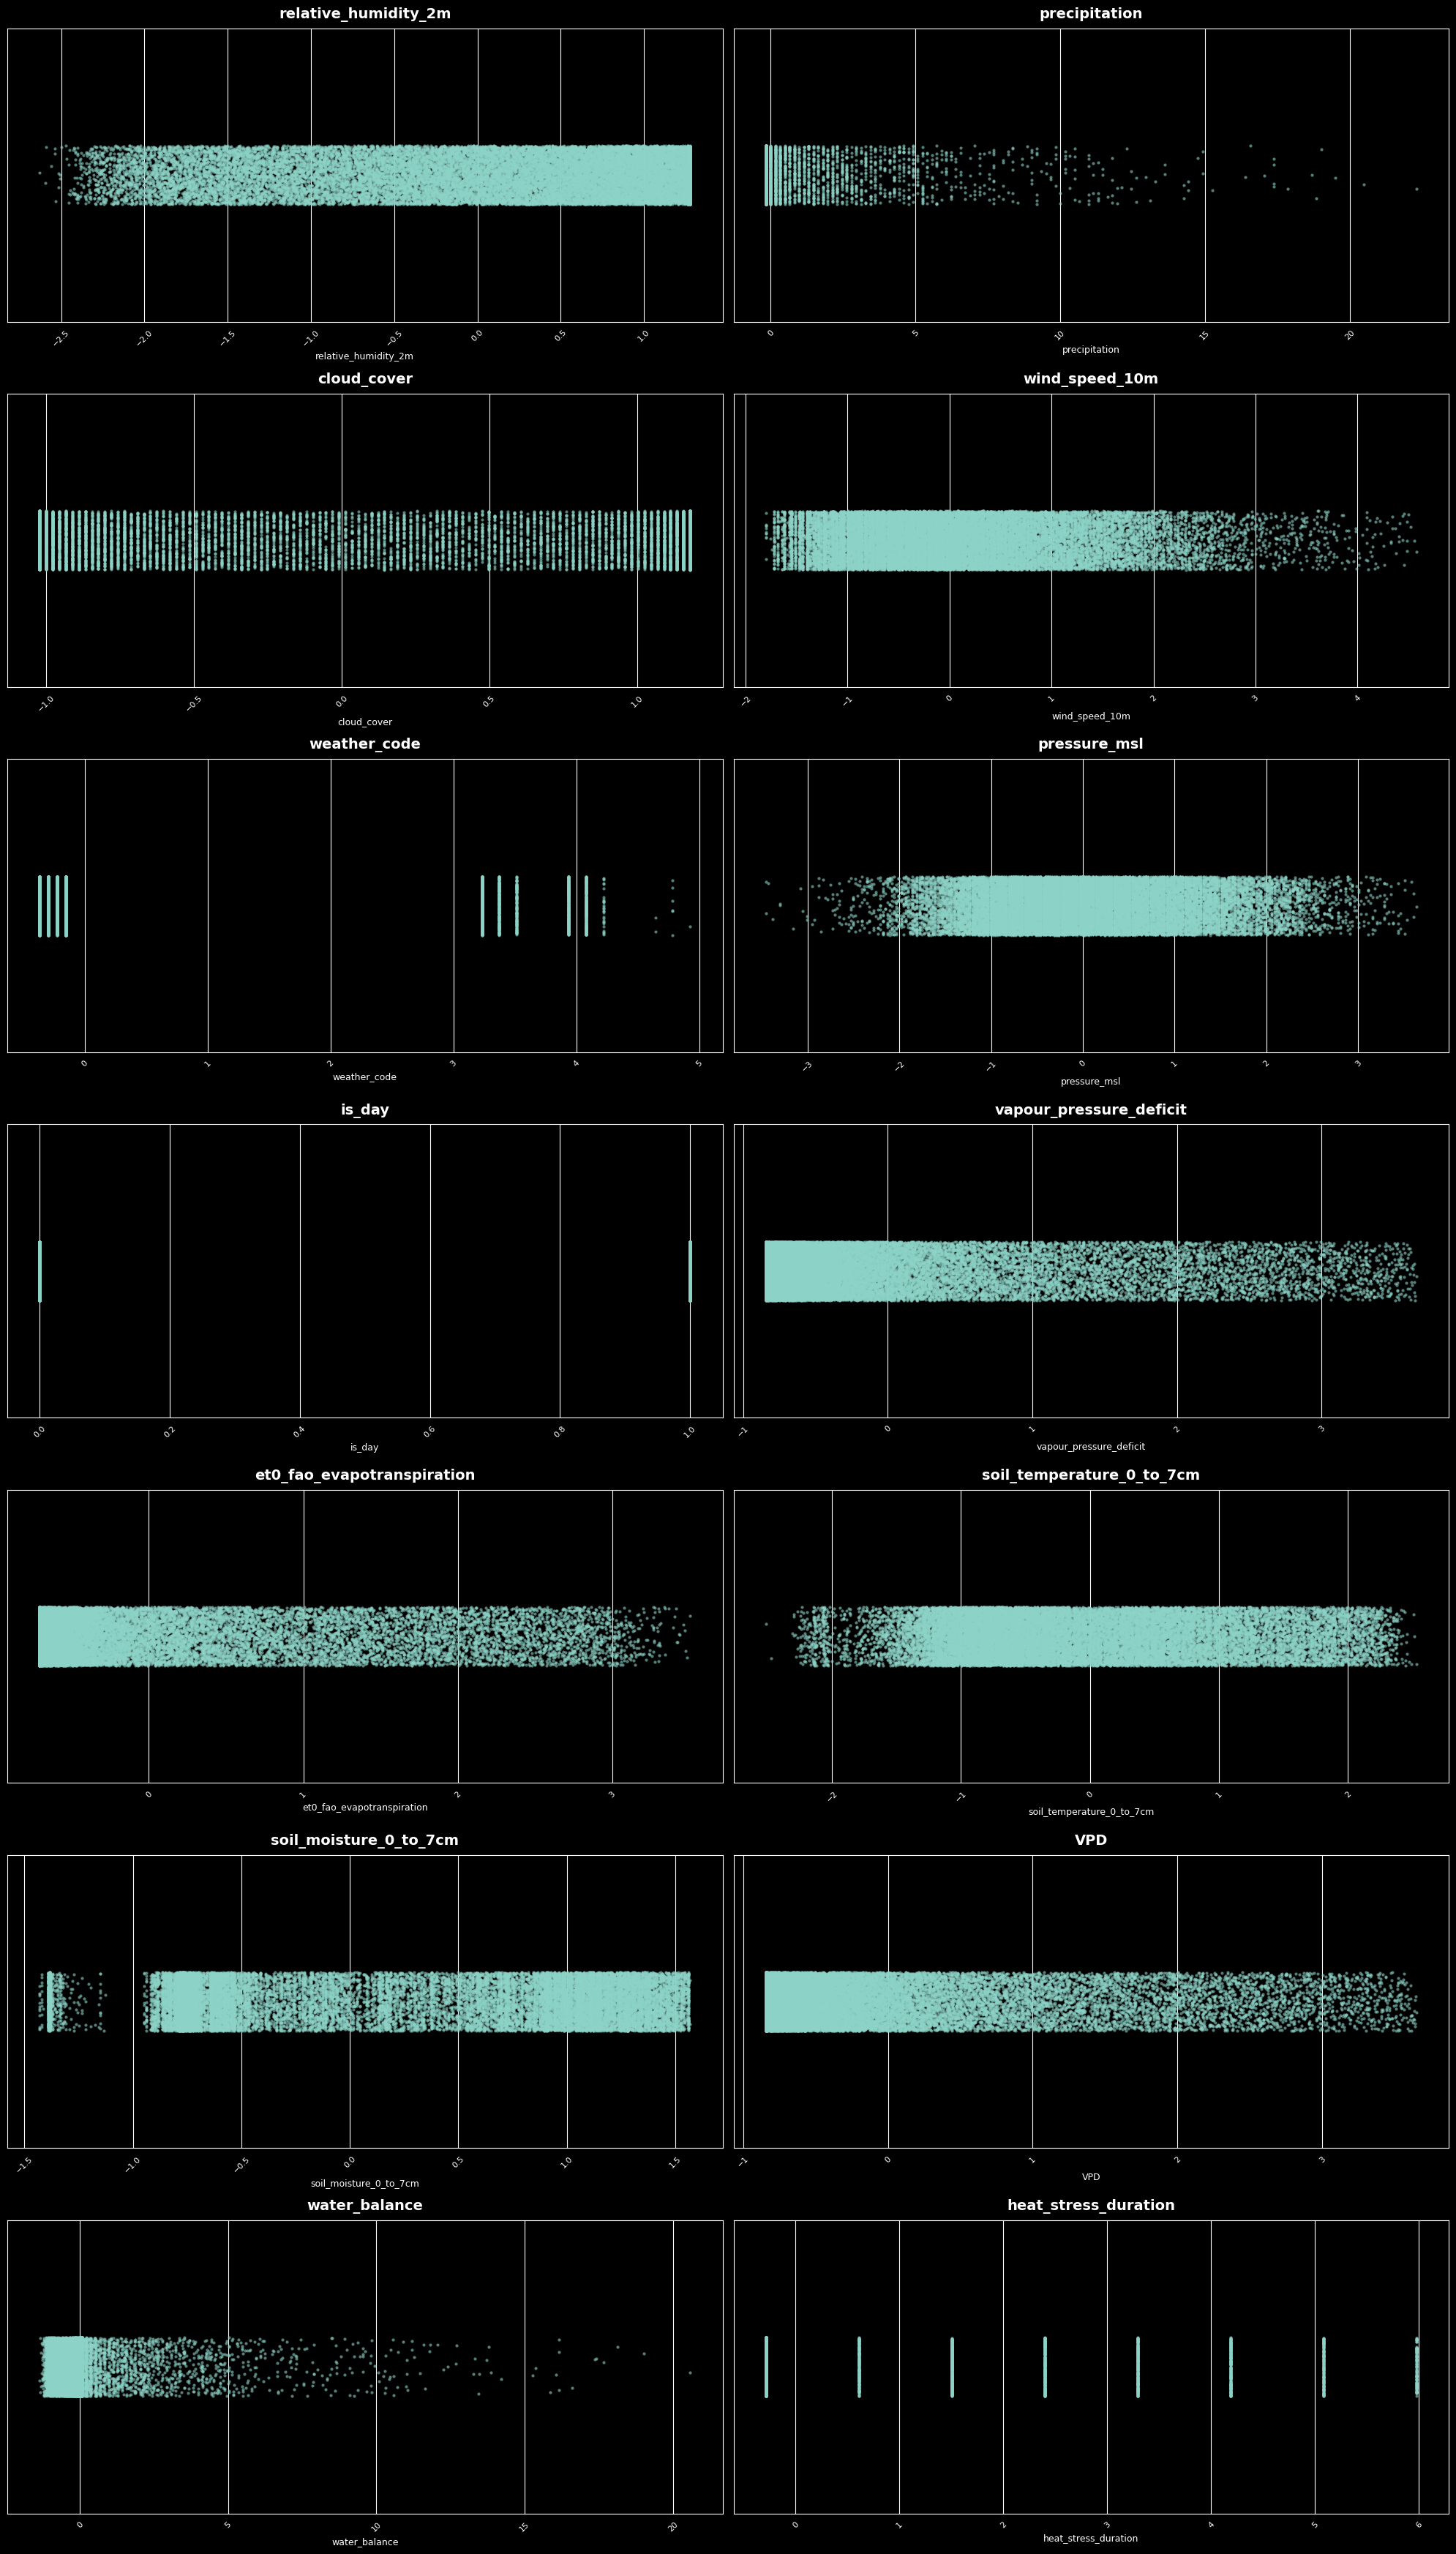

In [7]:
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
# Configurar grilla
ncols = 2
nrows = (len(numeric_cols) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 5*nrows))
axes = axes.flatten()

for idx, var_check in enumerate(numeric_cols):
    ax = axes[idx]
    ax.set_title(var_check, fontsize=14, fontweight='semibold', pad=10)

    sns.stripplot(x=var_check, data=train_df, ax=ax, alpha=0.6, size=3)
    ax.set_xlabel(var_check, fontsize=9)
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=45, labelsize=8)

    train_df.loc[train_df[var_check] > 1500, var_check] = np.nan
    nan_percentage = train_df[var_check].isna().sum() / len(train_df) * 100
    print(f"Porcentaje de NaN en {var_check}: {nan_percentage:.2f}%")
# Ocultar subplots vacíos
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)
plt.tight_layout()
plt.show()

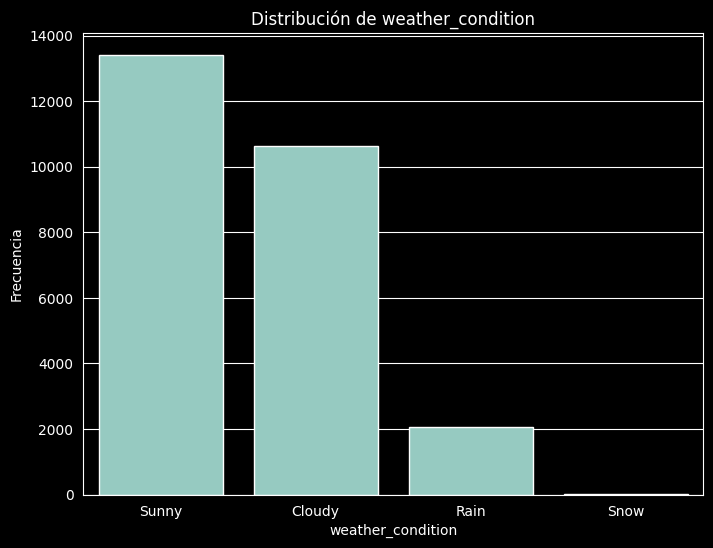

Distribución porcentual:
weather_condition
Sunny     51.374215
Cloudy    40.686725
Rain       7.904609
Snow       0.034451
Name: proportion, dtype: float64


In [8]:
var_check = 'weather_condition'
plt.figure(figsize=(8, 6))
sns.countplot(x=var_check, data=train_df)
plt.title(f'Distribución de {var_check}')
plt.xlabel(var_check)
plt.ylabel('Frecuencia')
plt.show()
print("Distribución porcentual:")
print(train_df['weather_condition'].value_counts(normalize=True) * 100)

## Selección de Variables (Feature Selection)

Ver con `SelectKBest` las variables que más aportan al modelo, reduciendo la redundancia.

In [9]:
from sklearn.feature_selection import SelectKBest, f_classif

X_temp = train_df.drop(columns=['date', 'weather_condition', 'weather_code'])
y_temp = LabelEncoder().fit_transform(train_df['weather_condition'])

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_temp, y_temp)

scores = pd.DataFrame({'Feature': X_temp.columns, 'Score': selector.scores_})
scores = scores.sort_values(by='Score', ascending=False)
print("Top variables por importancia estadística")
print(scores)

Top variables por importancia estadística
                       Feature          Score
2                  cloud_cover  106492.381086
11               water_balance    4850.508847
1                precipitation    4829.826636
9       soil_moisture_0_to_7cm    3826.204859
8    soil_temperature_0_to_7cm    2657.139102
0         relative_humidity_2m    2544.915820
6      vapour_pressure_deficit    1727.970801
10                         VPD    1726.836969
7   et0_fao_evapotranspiration     813.128462
4                 pressure_msl     711.458319
3               wind_speed_10m     393.982796
12        heat_stress_duration     376.173458
5                       is_day       5.907582


## Desbalance de Clases

Antes de entrenar, revisamos cuántos registros tenemos de cada condición climática. Un desbalance extremo (ej: 90% Sunny) hará que el modelo ignore las tormentas.

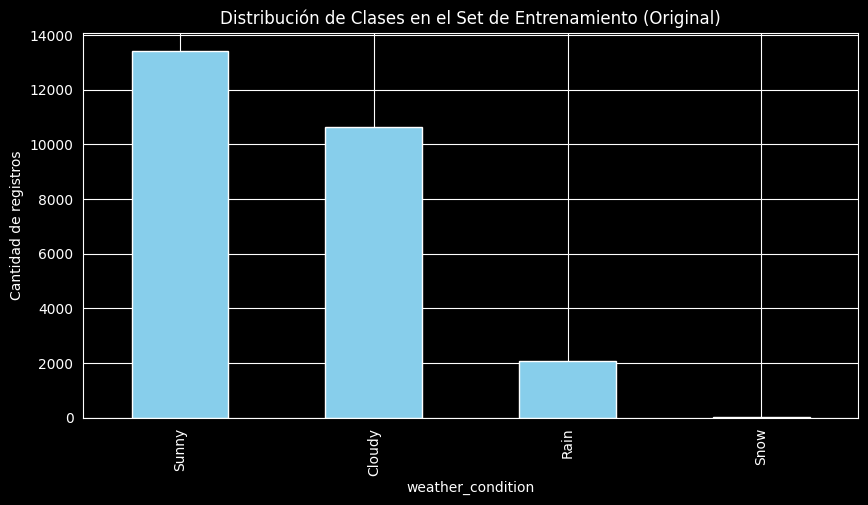

Distribución porcentual:
weather_condition
Sunny     51.374215
Cloudy    40.686725
Rain       7.904609
Snow       0.034451
Name: proportion, dtype: float64


In [10]:
plt.figure(figsize=(10, 5))
train_df['weather_condition'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribución de Clases en el Set de Entrenamiento (Original)')
plt.ylabel('Cantidad de registros')
plt.show()

print("Distribución porcentual:")
print(train_df['weather_condition'].value_counts(normalize=True) * 100)

## Técnicas de Balanceo (SMOTE)

Utilizaremos **SMOTE (Synthetic Minority Over-sampling Technique)**. A diferencia del sobremuestreo simple, SMOTE crea nuevos ejemplos sintéticos de las clases minoritarias interpolando entre los existentes.

In [11]:
# Separar Features y Target
X_train = train_df.drop(columns=['date', 'weather_condition', 'weather_code'])
y_train = train_df['weather_condition']

X_test = test_df.drop(columns=['date', 'weather_condition', 'weather_code'])
y_test = test_df['weather_condition']

# Codificar etiquetas
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Aplicar SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train_encoded)

print(f"Forma original de y_train: {np.bincount(y_train_encoded)}")
print(f"Nueva forma de y_train (balanceada): {np.bincount(y_train_res)}")

Forma original de y_train: [10629  2065     9 13421]
Nueva forma de y_train (balanceada): [13421 13421 13421 13421]


## Entrenamiento del Modelo

In [12]:
results_list = []
best_accuracy = 0
best_model = None
best_params = None
best_duration = 0

In [13]:
# Definir grilla de hiperparámetros para probar
param_grid = [
    {'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.1},
    {'n_estimators': 50, 'max_depth': 4, 'learning_rate': 0.1},
    {'n_estimators': 50, 'max_depth': 4, 'learning_rate': 0.2},
    {'n_estimators': 50, 'max_depth': 4, 'learning_rate': 0.3},

    {'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.2},
    {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1},

    {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1},
]

In [14]:
for i, params in enumerate(param_grid):
    start_t = time.time()
    # Crear y entrenar modelo con parámetros actuales
    current_model = xgb.XGBClassifier(
        **params,
        objective='multi:softprob',
        random_state=42,
        n_jobs=-1
    )
    current_model.fit(X_train_res, y_train_res)
    duration = time.time() - start_t
    # Evaluación en test
    y_pred_temp = current_model.predict(X_test)
    acc = accuracy_score(y_test_encoded, y_pred_temp)
    # Guardar resultados
    res = {
        'Iteración': i + 1,
        'n_estimators': params['n_estimators'],
        'max_depth': params['max_depth'],
        'learning_rate': params['learning_rate'],
        'Accuracy': round(acc, 5),
        'Tiempo (s)': round(duration, 2)
    }
    results_list.append(res)
    
    print(f"Iteración {i+1}: {params} -> Accuracy: {acc:.4f} ({duration:.2f}s)")
    
    if acc > best_accuracy:
        best_accuracy = acc
        best_model = current_model
        best_params = params
        best_duration = duration

Iteración 1: {'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.1} -> Accuracy: 0.9980 (1.67s)
Iteración 2: {'n_estimators': 50, 'max_depth': 4, 'learning_rate': 0.1} -> Accuracy: 0.9988 (1.70s)
Iteración 3: {'n_estimators': 50, 'max_depth': 4, 'learning_rate': 0.2} -> Accuracy: 0.9989 (1.47s)
Iteración 4: {'n_estimators': 50, 'max_depth': 4, 'learning_rate': 0.3} -> Accuracy: 0.9990 (1.25s)
Iteración 5: {'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.2} -> Accuracy: 0.9990 (2.51s)
Iteración 6: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1} -> Accuracy: 0.9990 (3.09s)
Iteración 7: {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1} -> Accuracy: 0.9989 (5.22s)


Mejores parámetros: {'n_estimators': 50, 'max_depth': 4, 'learning_rate': 0.3}


,Iteración,n_estimators,max_depth,learning_rate,Accuracy,Tiempo (s)
5,6,100,5,0.1,0.99902,3.09
4,5,100,4,0.2,0.99902,2.51
3,4,50,4,0.3,0.99902,1.25
2,3,50,4,0.2,0.99893,1.47
6,7,200,6,0.1,0.99893,5.22
1,2,50,4,0.1,0.99884,1.70
0,1,50,3,0.1,0.99804,1.67


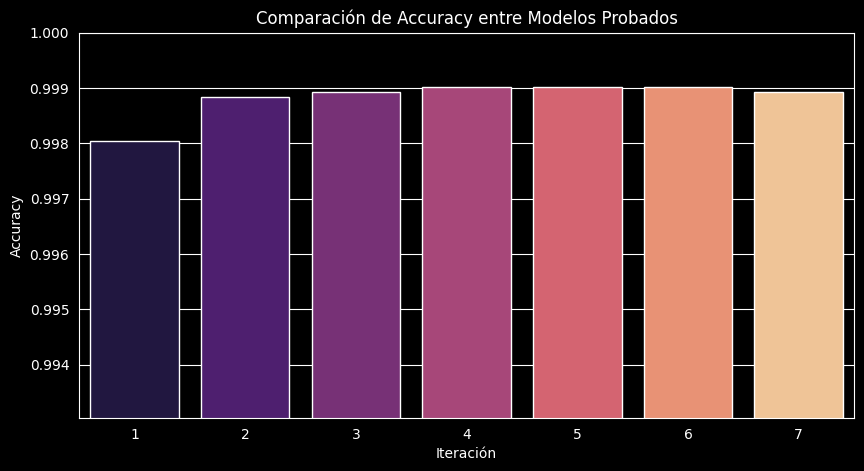

In [15]:
model = best_model
training_time = best_duration

print(f"Mejores parámetros: {best_params}")

# Mostrar tabla comparativa
comparison_df = pd.DataFrame(results_list).sort_values(by='Accuracy', ascending=False)
display(comparison_df)

# Graficar comparación de Accuracy
plt.figure(figsize=(10, 5))
sns.barplot(x='Iteración', y='Accuracy', data=comparison_df, palette='magma')
plt.title('Comparación de Accuracy entre Modelos Probados')
plt.ylim(comparison_df['Accuracy'].min() - 0.005, min(1.0, comparison_df['Accuracy'].max() + 0.005))
plt.show()

## Evaluación y Resultados

Classification Report:
              precision    recall  f1-score   support

      Cloudy       1.00      1.00      1.00      3936
        Rain       0.99      0.99      0.99       604
        Snow       0.20      0.12      0.15         8
       Sunny       1.00      1.00      1.00      6648

    accuracy                           1.00     11196
   macro avg       0.80      0.78      0.79     11196
weighted avg       1.00      1.00      1.00     11196



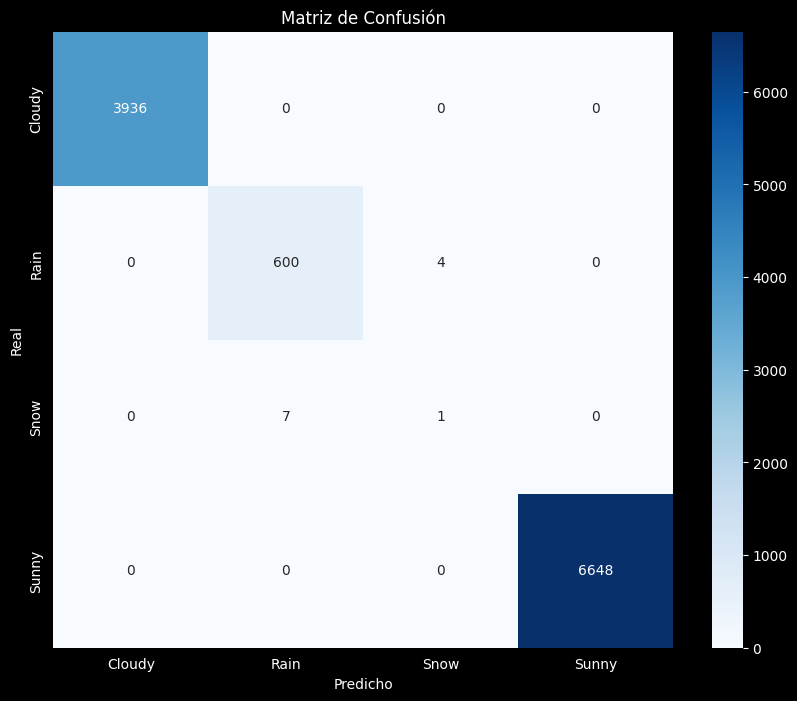

In [16]:
y_pred = model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test_encoded, y_pred, target_names=le.classes_))

# Matriz de Confusión
cm = confusion_matrix(y_test_encoded, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.title('Matriz de Confusión')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

## Importancia de las Variables

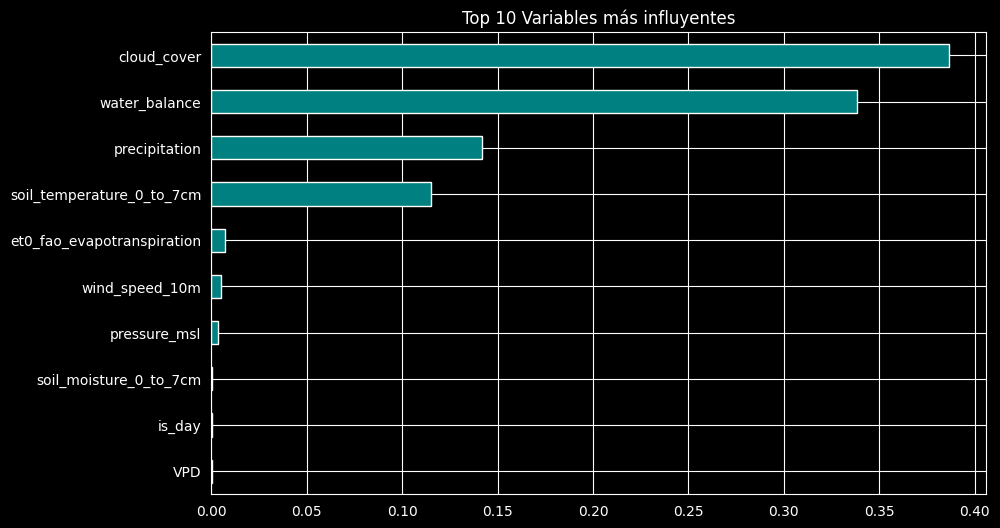

In [17]:
feat_importances = pd.Series(model.feature_importances_, index=X_train.columns)
plt.figure(figsize=(10, 6))
feat_importances.nlargest(10).sort_values().plot(kind='barh', color='teal')
plt.title('Top 10 Variables más influyentes')
plt.show()

## Guardar Modelo y Resumen Final

Guardamos el modelo para su posterior despliegue y mostramos un resumen de los resultados utilizando .

In [19]:
# Guardar el modelo
os.makedirs('outputs', exist_ok=True)
dump(model, 'outputs/xgboost_model.joblib')
dump(le, 'outputs/label_encoder_xgb.joblib')
print("Modelo y LabelEncoder guardados en la carpeta 'outputs'.")

# Tabla de resumen
table = Table(title="Resumen de Entrenamiento XGBoost")
table.add_column("Métrica", style="cyan")
table.add_column("Valor")

table.add_row("Precisión (Accuracy)", f"{accuracy_score(y_test_encoded, y_pred):.4f}")
table.add_row("Tiempo de Entrenamiento", f"{training_time:.2f} s")
table.add_row("Registros Train (Balanceados)", str(len(X_train_res)))
table.add_row("Registros Test", str(len(y_test)))

console.print(table)

Modelo y LabelEncoder guardados en la carpeta 'outputs'.


     Resumen de Entrenamiento XGBoost     
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃ Métrica                       ┃ Valor  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│ Precisión (Accuracy)          │ 0.9992 │
│ Tiempo de Entrenamiento       │ 0.97 s │
│ Registros Train (Balanceados) │ 53684  │
│ Registros Test                │ 11196  │
└───────────────────────────────┴────────┘